### TP Final - PINN para Helmholtz 2D

Resolvemos la ecuacion de Helmholtz en 2D con una PINN (TensorFlow / Keras). La idea es replicar la primera mejora del paper de Wang, Teng y Perdikaris (2021), que mete un peso adaptativo entre el residuo de la PDE y la condicion de borde. Comparamos:

- **M1**: PINN clasica, sin balance.
- **M2**: misma red, pero con el peso adaptativo del paper.

El grid de hiperparametros esta aparte en `Grid_Search.ipynb`.

In [154]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

print("TensorFlow", tf.__version__)


TensorFlow: 2.19.0 | Keras: 3.11.3


In [155]:
SEED = 0
keras.utils.set_random_seed(SEED)


### El problema

Helmholtz 2D en $[-1, 1]^2$ con $u = 0$ en el borde:

$$\Delta u + \lambda u = q$$

Fabricamos una solucion conocida $u = \sin(\pi x) \sin(4\pi y)$ y de ahi sacamos el forcing $q$ derivando dos veces. Da $q \approx -167 \cdot u$, lo que vuelve duro al problema (los gradientes del residuo dominan a los del borde).

In [156]:
LAMBDA = 1.0
A1, A2 = 1.0, 4.0


In [157]:
def u_exacta(x):
    return np.sin(A1 * np.pi * x[:, 0:1]) * np.sin(A2 * np.pi * x[:, 1:2])


In [158]:
def forcing(x):
    factor = -(A1 * np.pi)**2 - (A2 * np.pi)**2 + LAMBDA
    return factor * u_exacta(x)


Visualizamos $u$ y $q$ sobre una grilla 100x100.

In [159]:
n = 100
x_eje = np.linspace(-1, 1, n)
y_eje = np.linspace(-1, 1, n)
X1, X2 = np.meshgrid(x_eje, y_eje)
puntos = np.column_stack([X1.flatten(), X2.flatten()])

u_real_2d = u_exacta(puntos).reshape(n, n)
q_real_2d = forcing(puntos).reshape(n, n)


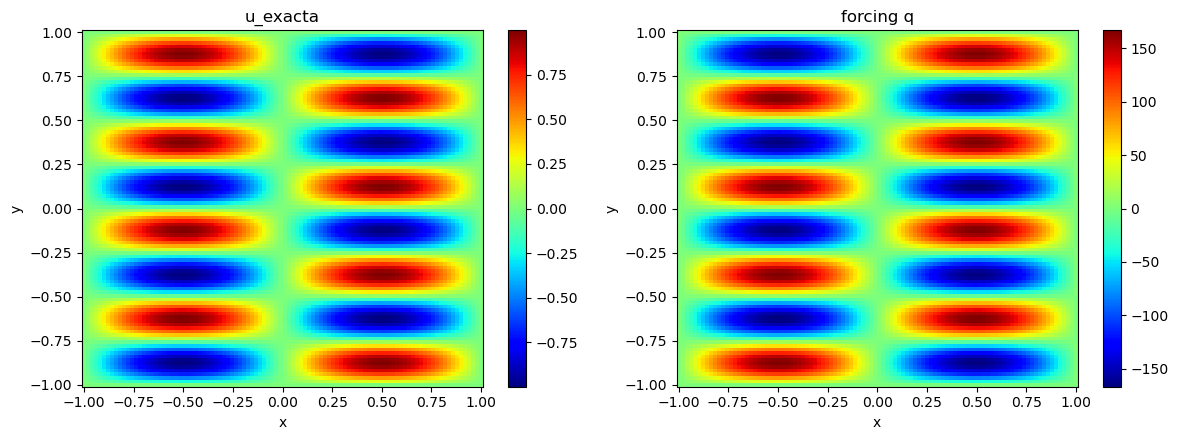

In [160]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
im0 = axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto")
axes[0].set_title("u_exacta")
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].pcolormesh(X1, X2, q_real_2d, cmap="jet", shading="auto")
axes[1].set_title("forcing q")
axes[1].set_xlabel("x"); axes[1].set_ylabel("y")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()


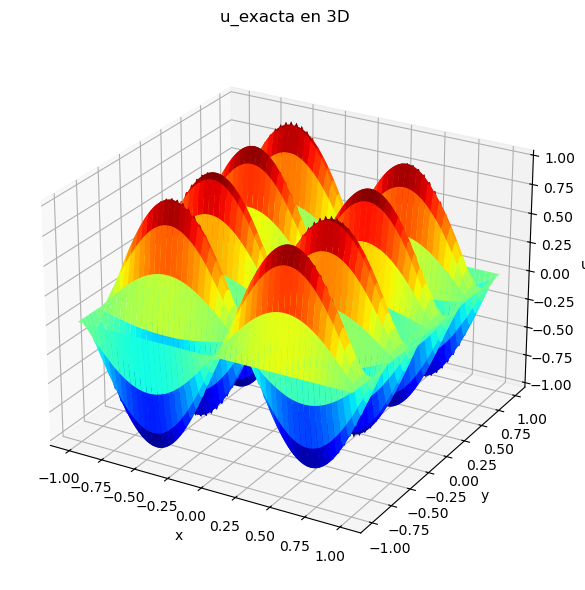

In [161]:
fig = plt.figure(figsize=(9, 6))
ax = fig.add_subplot(111, projection="3d")
ax.plot_surface(X1, X2, u_real_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u")
ax.set_title("u_exacta en 3D")
ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()


### Samplers

In [162]:
def muestrear_interior(n):
    return np.random.uniform(-1, 1, size=(n, 2)).astype(np.float32)


def muestrear_borde(n):
    m = n // 4
    abajo  = np.column_stack([np.random.uniform(-1, 1, m), -np.ones(m)])
    arriba = np.column_stack([np.random.uniform(-1, 1, m),  np.ones(m)])
    izq    = np.column_stack([-np.ones(m), np.random.uniform(-1, 1, m)])
    der    = np.column_stack([ np.ones(m), np.random.uniform(-1, 1, m)])
    return np.vstack([abajo, arriba, izq, der]).astype(np.float32)


En cada iteracion tomamos puntos nuevos: del interior para la PDE y del borde para imponer $u = 0$.

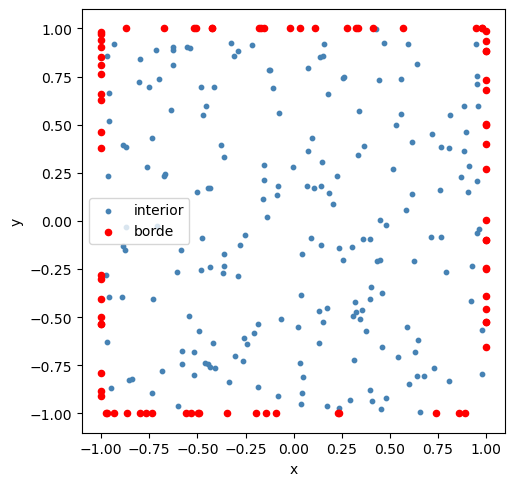

In [163]:
pts_int = muestrear_interior(200)
pts_bnd = muestrear_borde(80)

plt.figure(figsize=(5.5, 5.5))
plt.scatter(pts_int[:, 0], pts_int[:, 1], s=10, c="steelblue", label="interior")
plt.scatter(pts_bnd[:, 0], pts_bnd[:, 1], s=20, c="red", label="borde")
plt.xlim(-1.1, 1.1); plt.ylim(-1.1, 1.1)
plt.xlabel("x"); plt.ylabel("y")
plt.gca().set_aspect("equal")
plt.legend()
plt.show()


### La red

MLP con `tanh` (la derivada segunda existe, necesario para $u_{xx}$ y $u_{yy}$). Salida lineal e inicializacion Glorot.

In [164]:
from keras.models import Sequential
from keras.layers import Dense, Input


def construir_red(capas):
    red = Sequential()
    red.add(Input(shape=(capas[0],)))
    for ancho in capas[1:-1]:
        red.add(Dense(ancho, activation="tanh",
                      kernel_initializer="glorot_normal",
                      bias_initializer="zeros"))
    red.add(Dense(capas[-1], activation=None,
                  kernel_initializer="glorot_normal",
                  bias_initializer="zeros"))
    return red


In [165]:
red_prueba = construir_red([2, 50, 50, 50, 1])
red_prueba.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 50)             │           150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 50)             │         2,550 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,301 (20.71 KB)

 Trainable params: 5,301 (20.71 KB)

 Non-trainable params: 0 (0.00 B)

### Residuo de la PDE

Para calcular $u_{xx} + u_{yy} + \lambda u$ usamos dos `tf.GradientTape` anidados (uno para las derivadas primeras, otro para las segundas).

In [166]:
def calcular_residuo(red, puntos):
    x = tf.convert_to_tensor(puntos[:, 0:1], dtype=tf.float32)
    y = tf.convert_to_tensor(puntos[:, 1:2], dtype=tf.float32)

    # Dos tapes anidados: el de afuera deriva las salidas del de adentro,
    # asi obtenemos u_xx y u_yy.
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x); tape2.watch(y)
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(x); tape1.watch(y)
            u = red(tf.concat([x, y], axis=1))
        u_x = tape1.gradient(u, x)
        u_y = tape1.gradient(u, y)
    u_xx = tape2.gradient(u_x, x)
    u_yy = tape2.gradient(u_y, y)
    del tape1, tape2

    return u_xx + u_yy + LAMBDA * u


### M1: sin balance

Baseline siguiendo Raissi (2019). La perdida es la suma directa $L = L_{res} + L_{bc}$, sin pesos. Entrenamos 40000 iteraciones de Adam con decaimiento exponencial del learning rate.

In [167]:
keras.utils.set_random_seed(SEED)
red_m1 = construir_red([2, 50, 50, 50, 1])

schedule_m1 = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001, decay_steps=1000,
    decay_rate=0.9, staircase=False,
)
optimizador_m1 = keras.optimizers.Adam(learning_rate=schedule_m1)
hist_m1 = {"iter": [], "L_res": [], "L_bc": [], "lambda_bc": []}


In [168]:
batch = 128
n_iter = 40000

for it in range(n_iter):
    # En cada iteracion remuestreamos los puntos del interior y del borde.
    pts_int_np = muestrear_interior(batch)
    pts_bnd_np = muestrear_borde(batch)
    q_obj = tf.constant(forcing(pts_int_np), dtype=tf.float32)
    pts_bnd = tf.constant(pts_bnd_np)

    with tf.GradientTape() as tape:
        r_pred = calcular_residuo(red_m1, pts_int_np)
        L_res = tf.reduce_mean((r_pred - q_obj) ** 2)
        L_bc = tf.reduce_mean(red_m1(pts_bnd) ** 2)
        perdida = L_res + L_bc

    grads = tape.gradient(perdida, red_m1.trainable_variables)
    optimizador_m1.apply_gradients(zip(grads, red_m1.trainable_variables))

    if it % 10 == 0:
        hist_m1["iter"].append(it)
        hist_m1["L_res"].append(float(L_res))
        hist_m1["L_bc"].append(float(L_bc))
        hist_m1["lambda_bc"].append(1.0)

    if it % 1000 == 0:
        print(f"  iter {it:5d}  L_res={float(L_res):12.4f}  L_bc={float(L_bc):10.4f}")

print("Listo M1.")


  iter     0  L_res=   7221.8447  L_bc=    0.0094
  iter  1000  L_res=   5014.6104  L_bc=   13.4598
  iter  2000  L_res=    108.2680  L_bc=   10.3559
  iter  3000  L_res=     34.4960  L_bc=    4.0936
  iter  4000  L_res=     12.5015  L_bc=    2.2616
  iter  5000  L_res=      9.8861  L_bc=    1.4221
  iter  6000  L_res=      6.1415  L_bc=    1.0945
  iter  7000  L_res=      2.8335  L_bc=    0.7354
  iter  8000  L_res=      2.4879  L_bc=    0.5883
  iter  9000  L_res=      3.6039  L_bc=    0.4676
  iter 10000  L_res=      1.9082  L_bc=    0.4176
  iter 11000  L_res=      1.4140  L_bc=    0.2891
  iter 12000  L_res=      2.2488  L_bc=    0.3231
  iter 13000  L_res=      1.0824  L_bc=    0.2943
  iter 14000  L_res=      1.0658  L_bc=    0.2174
  iter 15000  L_res=      1.4187  L_bc=    0.2219
  iter 16000  L_res=      1.1694  L_bc=    0.2230
  iter 17000  L_res=      0.8544  L_bc=    0.1574
  iter 18000  L_res=      1.2370  L_bc=    0.1891
  iter 19000  L_res=      0.9721  L_bc=    0.1611


**Evaluacion de M1**

Error medido como $L^2$ relativo: $\|u_{real} - u_{pred}\|_2 / \|u_{real}\|_2$.

In [169]:
u_pred_m1 = red_m1(tf.constant(puntos, dtype=tf.float32)).numpy().flatten()
u_pred_m1_2d = u_pred_m1.reshape(n, n)
error_m1 = np.linalg.norm(u_real_2d.flatten() - u_pred_m1) / np.linalg.norm(u_real_2d.flatten())
print(f"M1: error L2 = {error_m1:.6f}")


M1: error L2 = 0.351743


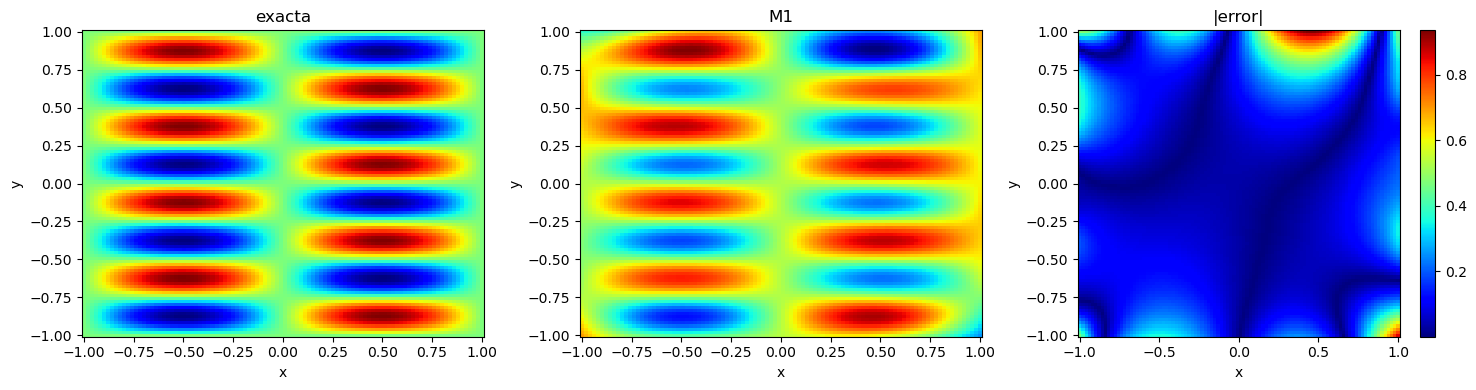

In [170]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto")
axes[0].set_title("exacta")
axes[1].pcolormesh(X1, X2, u_pred_m1_2d, cmap="jet", shading="auto")
axes[1].set_title("M1")
im = axes[2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m1_2d), cmap="jet", shading="auto")
axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


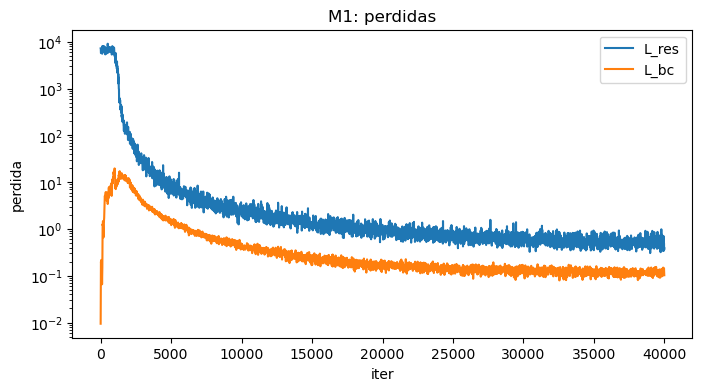

In [171]:
plt.figure(figsize=(8, 4))
plt.plot(hist_m1["iter"], hist_m1["L_res"], label="L_res")
plt.plot(hist_m1["iter"], hist_m1["L_bc"], label="L_bc")
plt.yscale("log")
plt.xlabel("iter"); plt.ylabel("perdida")
plt.title("M1: perdidas")
plt.legend()
plt.show()


**Patologia de gradientes (Figura 2 del paper)**

Histogramas de los gradientes de $L_{res}$ y $L_{bc}$ por capa. Si los azules (residuo) son mucho mas anchos que los rojos (borde), hay desbalance.

In [172]:
pts_int_hist = muestrear_interior(256)
pts_bnd_hist = muestrear_borde(256)
q_obj_hist = tf.constant(forcing(pts_int_hist), dtype=tf.float32)
pts_bnd_hist_tf = tf.constant(pts_bnd_hist)

with tf.GradientTape(persistent=True) as tape_hist:
    r_pred_hist = calcular_residuo(red_m1, pts_int_hist)
    L_res_hist = tf.reduce_mean((r_pred_hist - q_obj_hist) ** 2)
    L_bc_hist = tf.reduce_mean(red_m1(pts_bnd_hist_tf) ** 2)


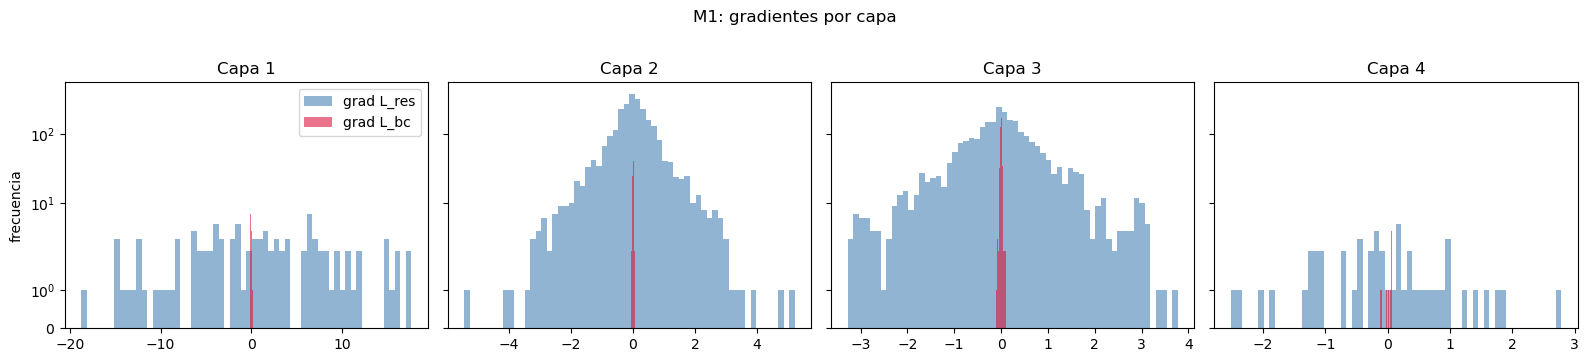

In [173]:
n_capas = len(red_m1.layers)
fig, axes = plt.subplots(1, n_capas, figsize=(4 * n_capas, 3.5), sharey=True)
for i, capa in enumerate(red_m1.layers):
    g_res = tape_hist.gradient(L_res_hist, capa.kernel).numpy().flatten()
    g_bc = tape_hist.gradient(L_bc_hist, capa.kernel).numpy().flatten()
    axes[i].hist(g_res, bins=60, alpha=0.6, color="steelblue", label="grad L_res")
    axes[i].hist(g_bc, bins=60, alpha=0.6, color="crimson", label="grad L_bc")
    axes[i].set_title(f"Capa {i + 1}")
    axes[i].set_yscale("symlog")
    if i == 0:
        axes[i].set_ylabel("frecuencia")
        axes[i].legend()
fig.suptitle("M1: gradientes por capa", y=1.02)
plt.tight_layout()
plt.show()

del tape_hist


### M2: con balance

Mismo entrenamiento, pero ahora la perdida es $L = L_{res} + \lambda_{bc} L_{bc}$. El peso $\lambda_{bc}$ no es fijo: se actualiza cada 10 iteraciones con la formula del paper, asi los gradientes del borde no se quedan chicos frente a los del residuo.

In [174]:
keras.utils.set_random_seed(SEED)
red_m2 = construir_red([2, 50, 50, 50, 1])

schedule_m2 = keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=0.001, decay_steps=1000, decay_rate=0.9, staircase=False,
)
optimizador_m2 = keras.optimizers.Adam(learning_rate=schedule_m2)
hist_m2 = {"iter": [], "L_res": [], "L_bc": [], "lambda_bc": []}
lambda_bc = 1.0


In [175]:
for it in range(n_iter):
    pts_int_np = muestrear_interior(batch)
    pts_bnd_np = muestrear_borde(batch)
    q_obj = tf.constant(forcing(pts_int_np), dtype=tf.float32)
    pts_bnd = tf.constant(pts_bnd_np)

    # Tape persistente: necesitamos sacar grad de L_res y de L_bc_pond por separado
    # para calcular el peso adaptativo.
    with tf.GradientTape(persistent=True) as tape:
        r_pred = calcular_residuo(red_m2, pts_int_np)
        L_res = tf.reduce_mean((r_pred - q_obj) ** 2)
        L_bc = tf.reduce_mean(red_m2(pts_bnd) ** 2)
        L_bc_pond = lambda_bc * L_bc
        perdida = L_res + L_bc_pond

    # Actualizacion adaptativa de lambda_bc cada 10 iters (Algoritmo 1 del paper).
    if it % 10 == 0 and it > 0:
        maxs_res, means_bc = [], []
        for capa in red_m2.layers:
            g_r = tape.gradient(L_res, capa.kernel)
            g_b = tape.gradient(L_bc_pond, capa.kernel)
            maxs_res.append(tf.reduce_max(tf.abs(g_r)))
            means_bc.append(tf.reduce_mean(tf.abs(g_b)))
        lambda_sug = float(tf.reduce_max(tf.stack(maxs_res)) /
                           tf.reduce_mean(tf.stack(means_bc)))
        lambda_bc = 0.9 * lambda_bc + 0.1 * lambda_sug

    grads = tape.gradient(perdida, red_m2.trainable_variables)
    optimizador_m2.apply_gradients(zip(grads, red_m2.trainable_variables))
    del tape

    if it % 10 == 0:
        hist_m2["iter"].append(it)
        hist_m2["L_res"].append(float(L_res))
        hist_m2["L_bc"].append(float(L_bc))
        hist_m2["lambda_bc"].append(lambda_bc)

    if it % 1000 == 0:
        print(f"  iter {it:5d}  L_res={float(L_res):12.4f}  L_bc={float(L_bc):10.4f}  lambda_bc={lambda_bc:7.2f}")

print(f"Listo M2. lambda_bc final = {lambda_bc:.2f}")


  iter     0  L_res=   7221.8447  L_bc=    0.0094  lambda_bc=   1.00
  iter  1000  L_res=   4020.7488  L_bc=    0.3976  lambda_bc=  86.27
  iter  2000  L_res=    149.0225  L_bc=    0.3518  lambda_bc=  86.69
  iter  3000  L_res=     42.9719  L_bc=    0.0847  lambda_bc=  79.48
  iter  4000  L_res=     23.3214  L_bc=    0.0299  lambda_bc= 115.90
  iter  5000  L_res=     12.7669  L_bc=    0.0269  lambda_bc= 107.31
  iter  6000  L_res=     15.0584  L_bc=    0.0197  lambda_bc= 117.51
  iter  7000  L_res=     12.7222  L_bc=    0.0220  lambda_bc= 111.42
  iter  8000  L_res=      8.7279  L_bc=    0.0178  lambda_bc= 100.50
  iter  9000  L_res=      6.8413  L_bc=    0.0193  lambda_bc=  98.28
  iter 10000  L_res=      6.0745  L_bc=    0.0133  lambda_bc= 107.90
  iter 11000  L_res=      5.1557  L_bc=    0.0113  lambda_bc= 103.52
  iter 12000  L_res=      5.4168  L_bc=    0.0091  lambda_bc= 139.53
  iter 13000  L_res=      3.5865  L_bc=    0.0091  lambda_bc= 128.97
  iter 14000  L_res=      2.8042  

In [176]:
u_pred_m2 = red_m2(tf.constant(puntos, dtype=tf.float32)).numpy().flatten()
u_pred_m2_2d = u_pred_m2.reshape(n, n)
error_m2 = np.linalg.norm(u_real_2d.flatten() - u_pred_m2) / np.linalg.norm(u_real_2d.flatten())
print(f"M2: error L2 = {error_m2:.6f}  (mejora {error_m1 / error_m2:.1f}x vs M1)")


M2: error L2 = 0.038733  (mejora 9.1x vs M1)


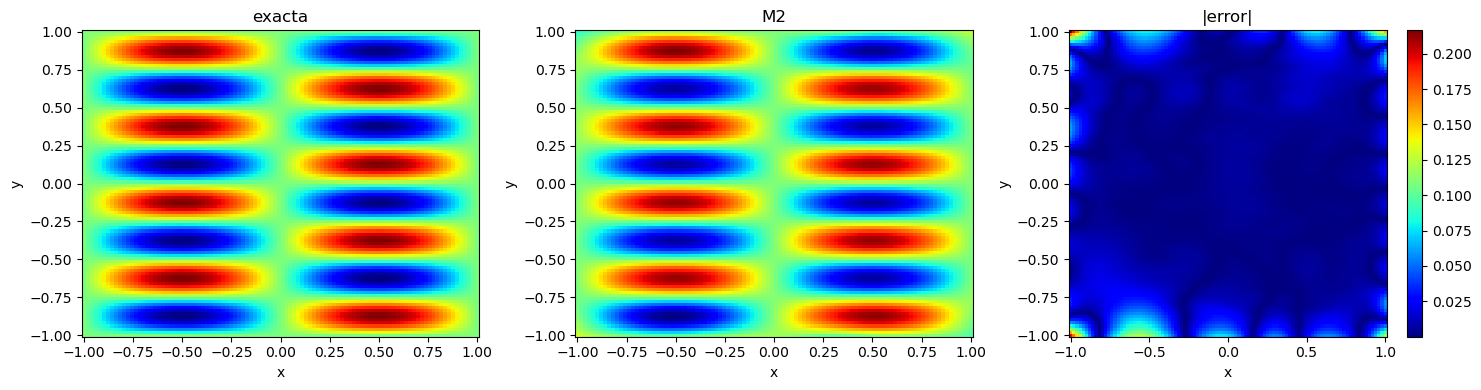

In [177]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].pcolormesh(X1, X2, u_real_2d, cmap="jet", shading="auto")
axes[0].set_title("exacta")
axes[1].pcolormesh(X1, X2, u_pred_m2_2d, cmap="jet", shading="auto")
axes[1].set_title("M2")
im = axes[2].pcolormesh(X1, X2, np.abs(u_real_2d - u_pred_m2_2d), cmap="jet", shading="auto")
axes[2].set_title("|error|")
for ax in axes:
    ax.set_xlabel("x"); ax.set_ylabel("y")
fig.colorbar(im, ax=axes[2])
plt.tight_layout()
plt.show()


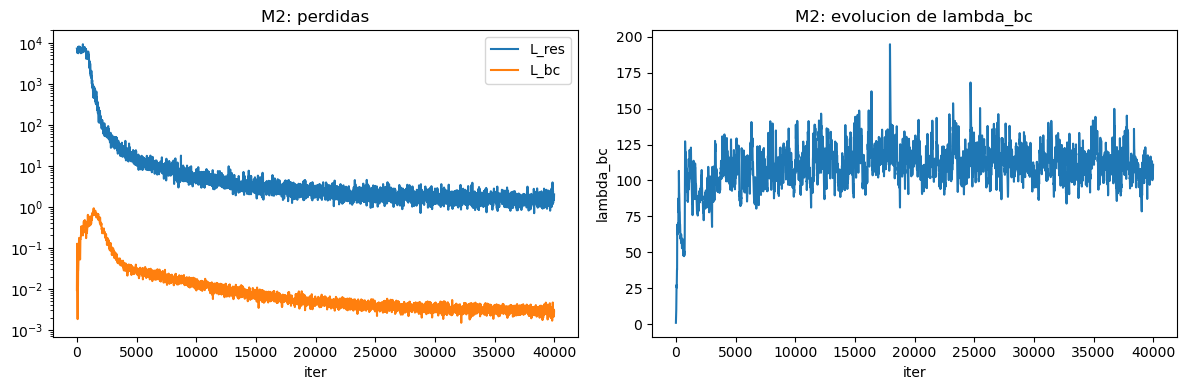

In [178]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(hist_m2["iter"], hist_m2["L_res"], label="L_res")
axes[0].plot(hist_m2["iter"], hist_m2["L_bc"], label="L_bc")
axes[0].set_yscale("log")
axes[0].set_xlabel("iter")
axes[0].set_title("M2: perdidas")
axes[0].legend()

axes[1].plot(hist_m2["iter"], hist_m2["lambda_bc"])
axes[1].set_xlabel("iter")
axes[1].set_ylabel("lambda_bc")
axes[1].set_title("M2: evolucion de lambda_bc")
plt.tight_layout()
plt.show()


**Gradientes con balance (Figura 7 del paper)**

Repetimos el histograma sobre M2. Los gradientes de $L_{res}$ y $\lambda_{bc} L_{bc}$ deberian quedar en el mismo orden.

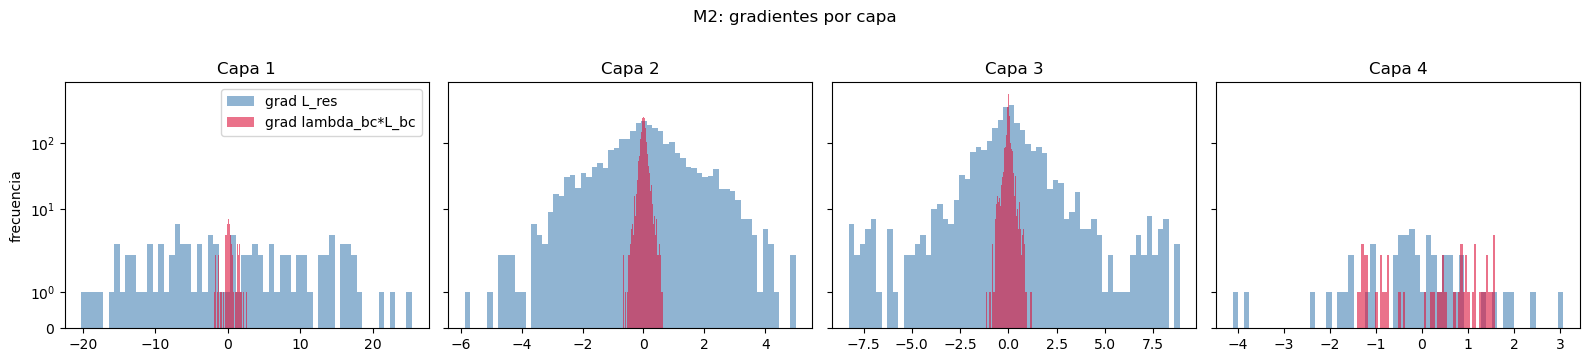

In [179]:
with tf.GradientTape(persistent=True) as tape_hist:
    r_pred_hist = calcular_residuo(red_m2, pts_int_hist)
    L_res_hist = tf.reduce_mean((r_pred_hist - q_obj_hist) ** 2)
    L_bc_hist = lambda_bc * tf.reduce_mean(red_m2(pts_bnd_hist_tf) ** 2)

fig, axes = plt.subplots(1, n_capas, figsize=(4 * n_capas, 3.5), sharey=True)
for i, capa in enumerate(red_m2.layers):
    g_res = tape_hist.gradient(L_res_hist, capa.kernel).numpy().flatten()
    g_bc = tape_hist.gradient(L_bc_hist, capa.kernel).numpy().flatten()
    axes[i].hist(g_res, bins=60, alpha=0.6, color="steelblue", label="grad L_res")
    axes[i].hist(g_bc, bins=60, alpha=0.6, color="crimson", label="grad lambda_bc*L_bc")
    axes[i].set_title(f"Capa {i + 1}")
    axes[i].set_yscale("symlog")
    if i == 0:
        axes[i].set_ylabel("frecuencia")
        axes[i].legend()
fig.suptitle("M2: gradientes por capa", y=1.02)
plt.tight_layout()
plt.show()

del tape_hist


### Comparacion 1D y 3D

Corte sobre $x = 0.5$, donde la exacta es $\sin(4\pi y)$. Permite ver de un vistazo que tan bien sigue cada PINN las 4 oscilaciones.

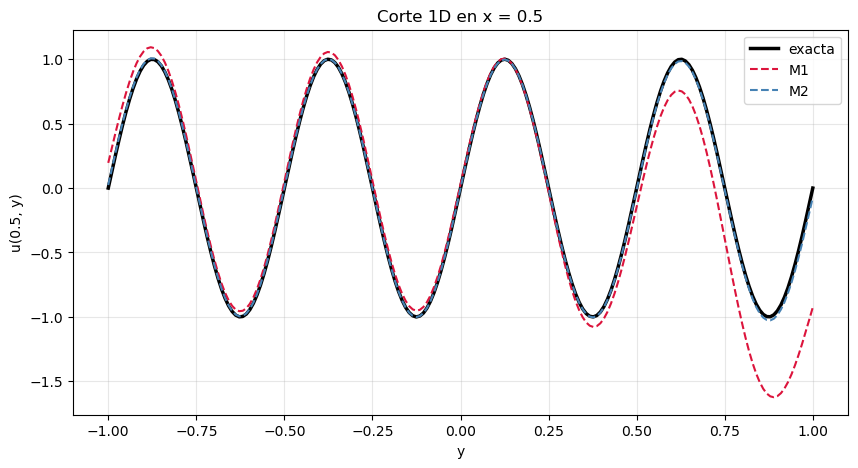

In [180]:
y_corte = np.linspace(-1, 1, 200)
pts_corte = np.column_stack([0.5 * np.ones(200), y_corte]).astype(np.float32)
u_real_corte = u_exacta(pts_corte).flatten()
u_m1_corte = red_m1(tf.constant(pts_corte)).numpy().flatten()
u_m2_corte = red_m2(tf.constant(pts_corte)).numpy().flatten()

plt.figure(figsize=(10, 5))
plt.plot(y_corte, u_real_corte, "k-", linewidth=2.5, label="exacta")
plt.plot(y_corte, u_m1_corte, "--", color="crimson", label="M1")
plt.plot(y_corte, u_m2_corte, "--", color="steelblue", label="M2")
plt.xlabel("y"); plt.ylabel("u(0.5, y)")
plt.title("Corte 1D en x = 0.5")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


Lo mismo en 3D.

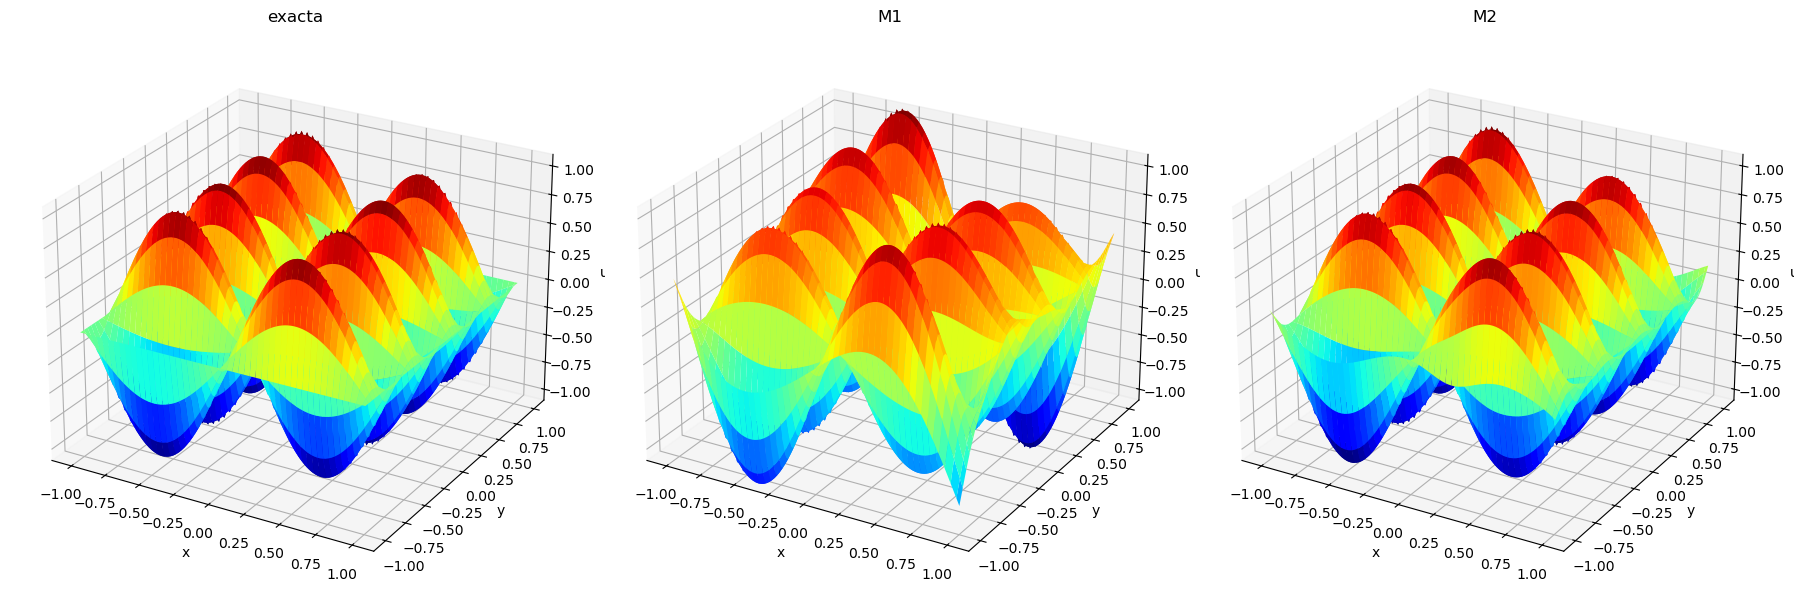

In [181]:
fig = plt.figure(figsize=(18, 6))
ax1 = fig.add_subplot(131, projection="3d")
ax1.plot_surface(X1, X2, u_real_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax1.set_title("exacta")

ax2 = fig.add_subplot(132, projection="3d")
ax2.plot_surface(X1, X2, u_pred_m1_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax2.set_title("M1")

ax3 = fig.add_subplot(133, projection="3d")
ax3.plot_surface(X1, X2, u_pred_m2_2d, cmap="jet", rstride=2, cstride=2, edgecolor="none")
ax3.set_title("M2")

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u")
    ax.set_zlim(-1.1, 1.1)
    ax.view_init(elev=25, azim=-60)
plt.tight_layout()
plt.show()


### Resumen

Errores L2 relativos:

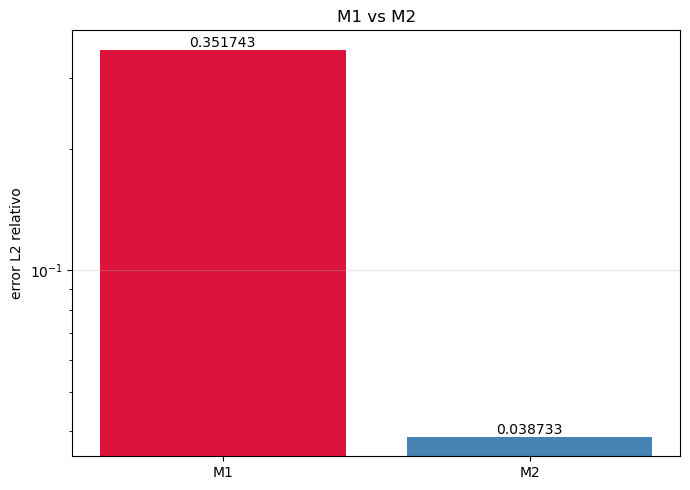

In [182]:
metodos = ["M1", "M2"]
errores_finales = [error_m1, error_m2]
colores = ["crimson", "steelblue"]

plt.figure(figsize=(7, 5))
barras = plt.bar(metodos, errores_finales, color=colores)
plt.yscale("log")
plt.ylabel("error L2 relativo")
plt.title("M1 vs M2")
for barra, valor in zip(barras, errores_finales):
    plt.text(barra.get_x() + barra.get_width() / 2, valor,
             f"{valor:.6f}", ha="center", va="bottom", fontsize=10)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
print(f"M1 (sin balance):  error = {error_m1:.6f}")
print(f"M2 (con balance):  error = {error_m2:.6f}")
print(f"\nMejora M1 -> M2:   {error_m1 / error_m2:.1f}x")
print(f"lambda_bc final:   {hist_m2['lambda_bc'][-1]:.2f}")

M1 (sin balance):  error = 0.351743
M2 (con balance):  error = 0.038733

Mejora M1 -> M2:   9.1x
lambda_bc final:   110.92
